In [254]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [255]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [256]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [263]:
"""
integrate_single_orbit.py

Usage:
    python integrate_single_orbit.py <tree_file> <subhalo_id>
"""

import config as cfg
import cosmo as co
import evolve as ev
from profiles import NFW, Green
from orbit import orbit

import numpy as np
import sys
import warnings
warnings.simplefilter("ignore", UserWarning)

cfg.lnL_pref = 0.75*2
cfg.evo_mode  = 'arbres'
cfg.phi_res   = 10**-4

def integrate_single(file, id, static_pot=False):

    f = np.load(file)
    redshift      = f['redshift']
    CosmicTime    = f['CosmicTime']
    mass          = f['mass']
    ParentID      = f['ParentID']
    concentration = f['concentration']
    coordinates   = f['coordinates']

    izmax             = mass.shape[1] - 1
    izroot            = mass.argmax(axis=1)
    VirialOverdensity = co.DeltaBN(redshift, cfg.Om, cfg.OL)

    ma        = mass[id, izroot[id]]
    min_mass  = cfg.phi_res * ma

    NFW_vectorized = np.vectorize(NFW) # grabbing the potential of the host at all times
    host_potentials = NFW_vectorized(mass[0, :], concentration[0,:], Delta=cfg.Dvsample, z=redshift)

    for iz in np.arange(izmax, 0, -1):
        iznext = iz - 1
        z   = redshift[iz]
        dt  = CosmicTime[iznext] - CosmicTime[iz]
        Dv  = VirialOverdensity[iz]
        ip  = ParentID[id, iz]

        # accretion: initialise subhalo and freeze host if static_pot
        if iz == izroot[id]:
            sub_potential = Green(ma, concentration[id, iz], Delta=Dv, z=z)
            orb      = orbit(coordinates[id, iz, :])
            trelease = CosmicTime[iz]

        # evolution
        if iz < izroot[id]:

            if static_pot:
                p = host_potentials[izroot[id]]
            else:
                p = host_potentials[iz]

            s  = sub_potential
            xv = orb.xv
            t  = CosmicTime[iznext] - trelease

            if s.Mh > min_mass:
                s.update_mass(mass[id, iz])

            alpha = ev.alpha_from_c2(p.ch, s.ch)
            m_old = s.Mh

            if m_old > min_mass:
                m, _ = ev.msub(s, p, xv, dt, choice='King62', alpha=alpha)
                orb.integrate(t, p, m_old)
                xv = orb.xv
            else:
                m  = m_old
                xv = np.array([cfg.Rres, 0., 0., 0., 0., 0.])

            mass[id, iznext]        = m
            coordinates[id, iznext] = xv

    return coordinates[id][:, 0], coordinates[id][:, 3], mass[id]


In [264]:
np.where(early.acc_order == 1)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74]),)

In [282]:
sub_index = 51

early = jsm_visualize.Tree_Vis(file="../../data/orbit_test/tree_early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
rs, vs, ms = integrate_single("../../data/orbit_test/tree_early_evo.npz", id=sub_index, static_pot=True)
r, v, m = integrate_single("../../data/orbit_test/tree_early_evo.npz", id=sub_index)

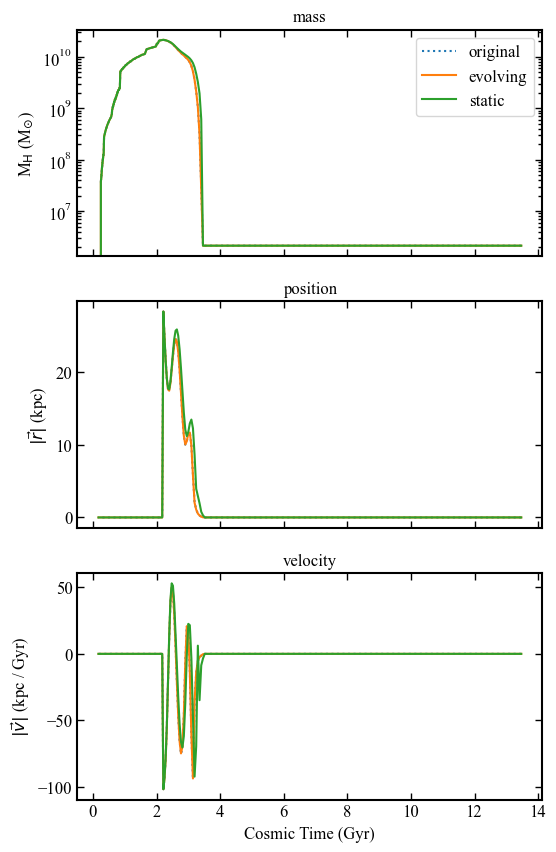

In [283]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(6,10))

ax[0].plot(early.CosmicTime, early.mass[sub_index-1], label="original", ls=":")
ax[0].plot(early.CosmicTime, m, label="evolving")
ax[0].plot(early.CosmicTime, ms, label="static")
ax[0].set_ylabel("M$_{\\rm H}$ (M$_{\odot}$)")
ax[0].legend()
ax[0].set_yscale("log")
ax[0].set_title("mass")


ax[1].plot(early.CosmicTime, early.coordinates[sub_index-1, :, 0], label="original", ls=":")
ax[1].plot(early.CosmicTime, r, label="evolving")
ax[1].plot(early.CosmicTime, rs, label="static")
ax[1].set_ylabel("$| \\vec{r} |$ (kpc)")
ax[1].set_title("position")

ax[2].plot(early.CosmicTime, early.coordinates[sub_index-1, :, 3], label="original", ls=":")
ax[2].plot(early.CosmicTime, v, label="evolving")
ax[2].plot(early.CosmicTime, vs, label="static")

ax[2].set_ylabel("$| \\vec{v} |$ (kpc / Gyr)")
ax[2].set_title("velocity")
ax[2].set_xlabel("Cosmic Time (Gyr)")
plt.show()